# Rossi Meshing Simulation — Analysis

Analysis of the pre-generated source distribution and 2D (r, θ) fission mesh tally.

1. **Source Distribution** — verify that the pre-generated source (`initial_source.h5`) is
   spatially uniform inside the core sphere.
2. **Fission Distribution** — visualise the fission tally on the 2D mesh (radial × polar)
   as both flat and physical-space heatmaps.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openmc
import scienceplots
from scipy import stats as sp_stats

from project.core.rossi_mesh import CORE_RADIUS, N_RADIAL, N_THETA, make_fission_mesh

plt.style.use(["science", "notebook", "grid", "high-vis"])

RESULTS_DIR = Path("../../results/rossi-meshing-simulation").resolve()
FIGURES_DIR = Path("../outputs/figures/rossi_meshing")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Reconstruct mesh
mesh = make_fission_mesh()
r_edges = np.asarray(mesh.r_grid)
theta_edges = np.asarray(mesh.theta_grid)
r_mid = 0.5 * (r_edges[:-1] + r_edges[1:])

# Load pre-generated source
df_src = openmc.read_source_file(str(RESULTS_DIR / "initial_source.h5")).to_dataframe()
mesh_ids = np.load(RESULTS_DIR / "source_mesh_ids.npy")

print(f"Mesh: {N_RADIAL} radial × {N_THETA} theta = {N_RADIAL * N_THETA:,} equal-volume cells")
print(f"Source particles loaded: {len(df_src):,}")
print(f"Results dir: {RESULTS_DIR}")

Mesh: 100 radial × 50 theta = 5,000 equal-volume cells
Source particles loaded: 1,000,000
Results dir: /home/itay/projects/initiation-project/project/results/rossi-meshing-simulation


## 1. Source Distribution Verification

The source file `initial_source.h5` was pre-generated by the simulation and used
via `FileSource` — these are the exact particles that were transported.

In [2]:
x = df_src["x"].to_numpy()
y = df_src["y"].to_numpy()
z = df_src["z"].to_numpy()
r = np.sqrt(x**2 + y**2 + z**2)

print(f"Max radius: {r.max():.5f} cm  (should be ≤ {CORE_RADIUS} cm)")
print(f"All inside core: {np.all(r <= CORE_RADIUS + 1e-9)}")

Max radius: 3.00000 cm  (should be ≤ 3.0 cm)
All inside core: True


### 1.1 Spatial distribution — x–z hexbin

Hexbin of the x–z projection. Uniform fill with no radial gradient confirms
the `PowerLaw(0, R, 2)` sampling produces a volumetrically uniform distribution.

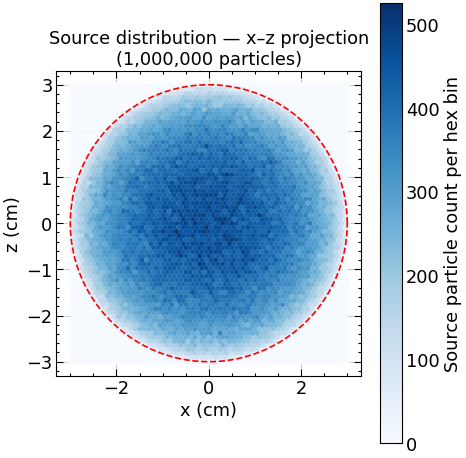

In [3]:
theta_ring = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots(figsize=(6, 6), dpi=80)
hb = ax.hexbin(x, z, gridsize=60, cmap="Blues", linewidths=0.2)
plt.colorbar(hb, ax=ax, label="Source particle count per hex bin")
ax.plot(
    CORE_RADIUS * np.cos(theta_ring),
    CORE_RADIUS * np.sin(theta_ring),
    "r--", lw=1.5,
)
ax.set_aspect("equal")
ax.set_xlabel("x (cm)")
ax.set_ylabel("z (cm)")
ax.set_title(f"Source distribution — x–z projection\n({len(df_src):,} particles)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "source_xz_hexbin.png", dpi=300, bbox_inches="tight")
plt.show()

### 1.2 Chi-squared uniformity test

With equal-volume mesh cells and a uniform source, each cell should contain
`N_particles / N_cells` particles on average. A chi-squared goodness-of-fit
test checks whether the observed cell counts are consistent with this expectation.

In [4]:
n_cells = N_RADIAL * N_THETA
cell_counts = np.bincount(mesh_ids[mesh_ids >= 0], minlength=n_cells)
expected = len(df_src) / n_cells

chi2_stat = np.sum((cell_counts - expected) ** 2 / expected)
p_value = 1.0 - sp_stats.chi2.cdf(chi2_stat, df=n_cells - 1)

rel_std_obs = cell_counts.std() / cell_counts.mean()
rel_std_poisson = 1.0 / np.sqrt(expected)

print(f"Expected particles per cell: {expected:.1f}")
print(f"Observed mean ± std: {cell_counts.mean():.1f} ± {cell_counts.std():.1f}")
print(f"Relative std: {rel_std_obs:.4f}  (Poisson expectation: {rel_std_poisson:.4f})")
print(f"Chi² statistic: {chi2_stat:.1f}  (df = {n_cells - 1})")
print(f"p-value: {p_value:.4f}")
print(f"Uniform distribution {'CONFIRMED' if p_value > 0.05 else 'REJECTED'} (α = 0.05)")

Expected particles per cell: 200.0
Observed mean ± std: 200.0 ± 14.3
Relative std: 0.0716  (Poisson expectation: 0.0707)
Chi² statistic: 5125.3  (df = 4999)
p-value: 0.1040
Uniform distribution CONFIRMED (α = 0.05)


### 1.3 Source counts per mesh cell — heatmaps

Two views of the same data: flat (r, cos θ) coordinates and a physical-space
meridional slice showing the actual sphere cross-section.

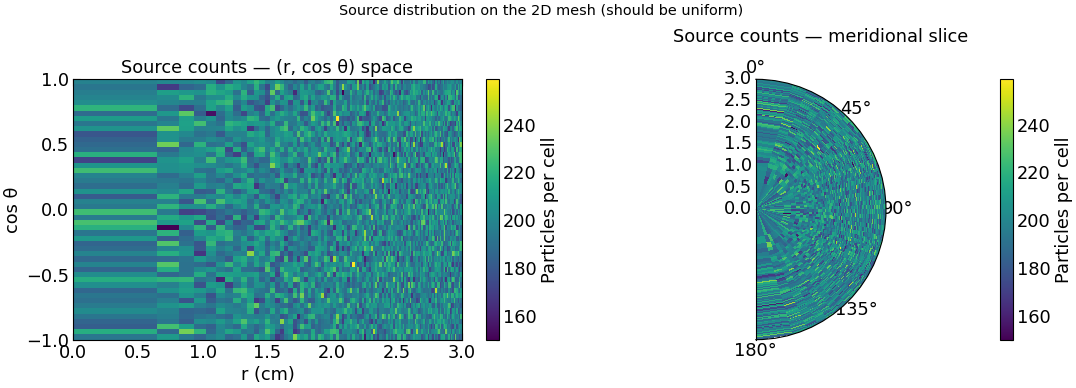

In [5]:
# Reshape counts to 2D: [i_theta, i_r] (r varies fastest in flat index)
counts_2d = cell_counts.reshape(N_THETA, N_RADIAL)

# Coordinate grids
cos_theta_edges = np.cos(theta_edges)

fig = plt.figure(figsize=(14, 5), dpi=80)

# Left: flat (r, cos θ) pcolormesh
ax0 = fig.add_subplot(1, 2, 1)
im0 = ax0.pcolormesh(
    r_edges, cos_theta_edges, counts_2d,
    cmap="viridis", shading="flat",
)
plt.colorbar(im0, ax=ax0, label="Particles per cell")
ax0.set_xlabel("r (cm)")
ax0.set_ylabel("cos θ")
ax0.set_title("Source counts — (r, cos θ) space")

# Right: polar meridional slice
ax1 = fig.add_subplot(1, 2, 2, projection="polar")
im1 = ax1.pcolormesh(
    theta_edges, r_edges, counts_2d.T,
    cmap="viridis", shading="flat",
)
plt.colorbar(im1, ax=ax1, label="Particles per cell", pad=0.1)
ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_thetamin(0)
ax1.set_thetamax(180)
ax1.set_title("Source counts — meridional slice", pad=15)

plt.suptitle("Source distribution on the 2D mesh (should be uniform)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "source_counts_2d.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Fission Distribution

Load the `fission_radial` mesh tally from the statepoint. Results are in units of
**fissions per source neutron per cell**. Because all cells have equal volume,
differences between cells reflect genuine spatial variation in the fission rate density.

In [6]:
sp = openmc.StatePoint(str(RESULTS_DIR / "statepoint.1.h5"))
tally = sp.get_tally(name="fission_radial")
mean = tally.mean.flatten()

# Reshape to 2D: [i_theta, i_r]
fission_2d = mean.reshape(N_THETA, N_RADIAL)

print(f"Tally cells: {len(mean):,}  (expected {N_RADIAL * N_THETA:,})")
print(f"Total fissions / source neutron: {mean.sum():.4e}")

Tally cells: 5,000  (expected 5,000)
Total fissions / source neutron: 1.4897e+01


### 2.1 Fission heatmaps — flat and physical space

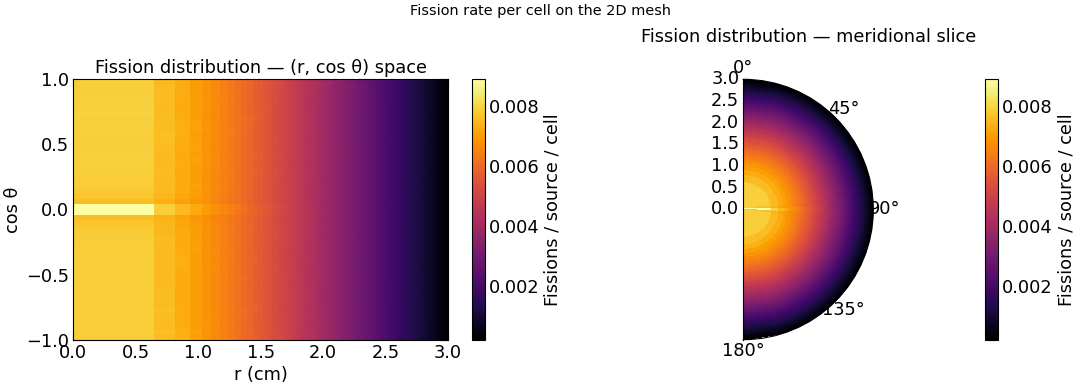

In [13]:
fig = plt.figure(figsize=(14, 5), dpi=80)

# Left: flat (r, cos θ) pcolormesh
ax0 = fig.add_subplot(1, 2, 1)
im0 = ax0.pcolormesh(
    r_edges, cos_theta_edges, fission_2d,
    cmap="inferno", shading="flat",
)
plt.colorbar(im0, ax=ax0, label="Fissions / source / cell")
ax0.set_xlabel("r (cm)")
ax0.set_ylabel("cos θ")
ax0.set_title("Fission distribution — (r, cos θ) space")

# Right: polar meridional slice
ax1 = fig.add_subplot(1, 2, 2, projection="polar")
im1 = ax1.pcolormesh(
    theta_edges, r_edges, fission_2d.T,
    cmap="inferno", shading="flat",
)
plt.colorbar(im1, ax=ax1, label="Fissions / source / cell", pad=0.1)
ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_thetamin(0)
ax1.set_thetamax(180)
ax1.set_title("Fission distribution — meridional slice", pad=15)

plt.suptitle("Fission rate per cell on the 2D mesh", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fission_2d.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.2 Radial profile (marginalised over θ)

Sum the 2D fission tally over the theta axis to recover the 1D radial profile.
This should reproduce the same trend as the old radial-only mesh results.

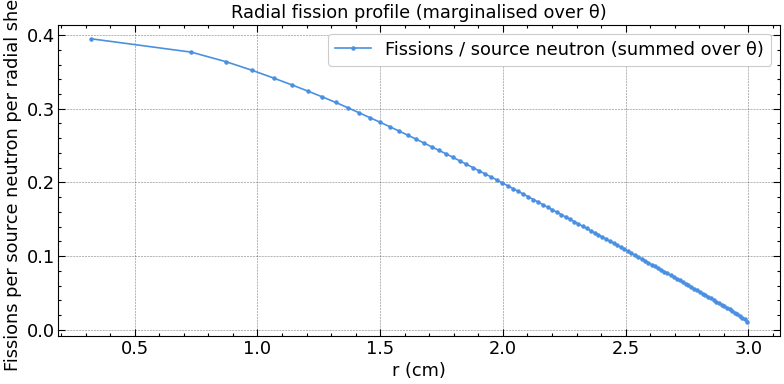

In [8]:
fission_radial = fission_2d.sum(axis=0)  # sum over theta

fig, ax = plt.subplots(figsize=(10, 5), dpi=80)
ax.plot(r_mid, fission_radial, "o-", color="#4A90E2", lw=1.5, ms=3,
        label="Fissions / source neutron (summed over θ)")
ax.set_xlabel("r (cm)")
ax.set_ylabel("Fissions per source neutron per radial shell")
ax.set_title("Radial fission profile (marginalised over θ)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fission_radial_profile.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Rossi-alpha Correlation

Compute the spatially-resolved Rossi quantity:

$$R(\tau) = \sum_i F_i \int g_i(t)\, g_i(t+\tau)\, dt$$

where $F_i$ is the fission rate in mesh cell $i$, and $g_i(t)$ is the detector
count rate for neutrons whose source neutron originated in cell $i$.

The integral is computed numerically: bin detection times per cell into uniform
time bins to form $g_i(t)$, then compute the shifted dot product for each lag $\tau$.

### 3.1 Load collision track and assign source cells

In [9]:
import h5py

with h5py.File(RESULTS_DIR / "collision_track.h5", "r") as f:
    track = f["collision_track_bank"][()]

det_times = track["time"]
det_parent_ids = track["parent_id"]

# Map each detection to its source mesh cell (OpenMC uses 1-based particle IDs)
det_cell_ids = mesh_ids[det_parent_ids - 1]

# Fission rate per cell (flat array, same indexing as mesh_ids)
F = mean  # already loaded from statepoint: fissions / source / cell

n_cells = N_RADIAL * N_THETA
print(f"Total detection events: {len(det_times):,}")
print(f"Unique source cells with detections: {len(np.unique(det_cell_ids)):,} / {n_cells:,}")
print(f"Detection time range: {det_times.min():.3e} – {det_times.max():.3e} s")

Total detection events: 152,876
Unique source cells with detections: 5,000 / 5,000
Detection time range: 2.792e-09 – 5.742e+02 s


### 3.2 Compute $R(\tau) = \sum_i F_i \int g_i(t)\, g_i(t+\tau)\, dt$

For each mesh cell $i$: bin its detection times into uniform bins to form $g_i(t)$,
then compute the autocorrelation at each lag $\tau$ via a shifted dot product.

In [10]:
TAU_MAX = 1e-2       # 10 ms — maximum lag
N_TAU = 256          # number of τ bins
T_MAX = 1.0          # 1 s — time range for g_i(t) histograms

dt = TAU_MAX / N_TAU
time_bins = np.arange(0, T_MAX + dt, dt)
n_t_bins = len(time_bins) - 1
tau_centers = np.linspace(dt / 2, TAU_MAX - dt / 2, N_TAU)

print(f"dt = {dt*1e6:.1f} μs,  n_t_bins = {n_t_bins:,},  τ range = [0, {TAU_MAX*1e3:.0f}] ms")

# Group detection indices by source cell
cell_event_indices = {}
for idx, cell_id in enumerate(det_cell_ids):
    cell_event_indices.setdefault(cell_id, []).append(idx)

R_tau = np.zeros(N_TAU)
cells_used = 0

for cell_i, event_indices in cell_event_indices.items():
    if len(event_indices) < 2:
        continue

    # Build g_i(t): histogram of detection times for this cell
    times_i = det_times[event_indices]
    g_i, _ = np.histogram(times_i, bins=time_bins)
    g_i = g_i.astype(np.float64)

    # Compute autocorrelation at each lag: ∫ g_i(t) · g_i(t+τ) dt
    F_i = F[cell_i]
    for k in range(N_TAU):
        lag = k + 1  # skip lag=0 (self-pairs)
        if lag < n_t_bins:
            R_tau[k] += F_i * np.dot(g_i[:-lag], g_i[lag:]) * dt

    cells_used += 1

print(f"Cells with ≥2 detections: {cells_used:,} / {n_cells:,}")
print(f"R(τ) range: [{R_tau.min():.4e}, {R_tau.max():.4e}]")

dt = 39.1 μs,  n_t_bins = 25,600,  τ range = [0, 10] ms
Cells with ≥2 detections: 4,999 / 5,000
R(τ) range: [6.5468e-08, 2.4858e-02]


### 3.3 Plot $R(\tau)$ and fit for $\alpha$

Fit: R(τ) = 4.9578e-06 + 2.6629e-02 · exp(-3581.7 · τ)
α = -3581.7 ± 2.3 s⁻¹
Decay time = 0.279 ms


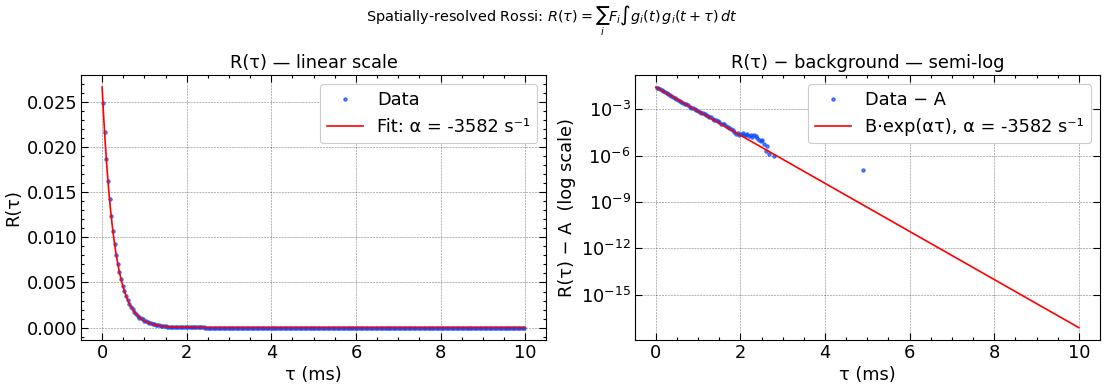

In [11]:
from scipy.optimize import curve_fit

def rossi_model(tau, A, B, alpha):
    """A + B * exp(alpha * tau), with alpha < 0 for decay."""
    return A + B * np.exp(alpha * tau)

# Fit — initial guesses
p0 = [R_tau[-1], R_tau[0] - R_tau[-1], -500.0]
popt, pcov = curve_fit(rossi_model, tau_centers, R_tau, p0=p0, maxfev=10000)
A_fit, B_fit, alpha_fit = popt
perr = np.sqrt(np.diag(pcov))

print(f"Fit: R(τ) = {A_fit:.4e} + {B_fit:.4e} · exp({alpha_fit:.1f} · τ)")
print(f"α = {alpha_fit:.1f} ± {perr[2]:.1f} s⁻¹")
print(f"Decay time = {-1/alpha_fit*1e3:.3f} ms")

tau_fine = np.linspace(0, TAU_MAX, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=80)

# Linear scale
axes[0].plot(tau_centers * 1e3, R_tau, "o", ms=3, alpha=0.7, label="Data")
axes[0].plot(tau_fine * 1e3, rossi_model(tau_fine, *popt), "r-", lw=1.5,
             label=f"Fit: α = {alpha_fit:.0f} s⁻¹")
axes[0].set_xlabel("τ (ms)")
axes[0].set_ylabel("R(τ)")
axes[0].set_title("R(τ) — linear scale")
axes[0].legend()

# Log scale (subtract background)
R_corr = R_tau - A_fit
R_corr_pos = np.where(R_corr > 0, R_corr, np.nan)
axes[1].semilogy(tau_centers * 1e3, R_corr_pos, "o", ms=3, alpha=0.7, label="Data − A")
axes[1].semilogy(tau_fine * 1e3, rossi_model(tau_fine, 0, B_fit, alpha_fit),
                 "r-", lw=1.5, label=f"B·exp(ατ), α = {alpha_fit:.0f} s⁻¹")
axes[1].set_xlabel("τ (ms)")
axes[1].set_ylabel("R(τ) − A  (log scale)")
axes[1].set_title("R(τ) − background — semi-log")
axes[1].legend()

plt.suptitle(r"Spatially-resolved Rossi: $R(\tau) = \sum_i F_i \int g_i(t)\, g_i(t+\tau)\, dt$",
             fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rossi_correlation.png", dpi=300, bbox_inches="tight")
plt.show()